# Random Forest: Intuition in One Example
### Wisdom of Crowds: Why 100 Trees > 1 Tree

**Video Title:** *Random Forest Explained: One Tree vs 100 Trees*

**The Core Idea:**
- Single Decision Tree: Can overfit (memorizes training data)
- Random Forest: 100 trees vote → Better generalization!
- **Ensemble Learning** = Combine multiple models

**Two Key Ingredients:**
1. **Bagging**: Bootstrap samples (random with replacement)
2. **Random Features**: Each split uses random subset of features

**Result:** Diverse trees → Better predictions! 🌳🌳🌳

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)

## 1. The Problem: Single Tree Can Overfit

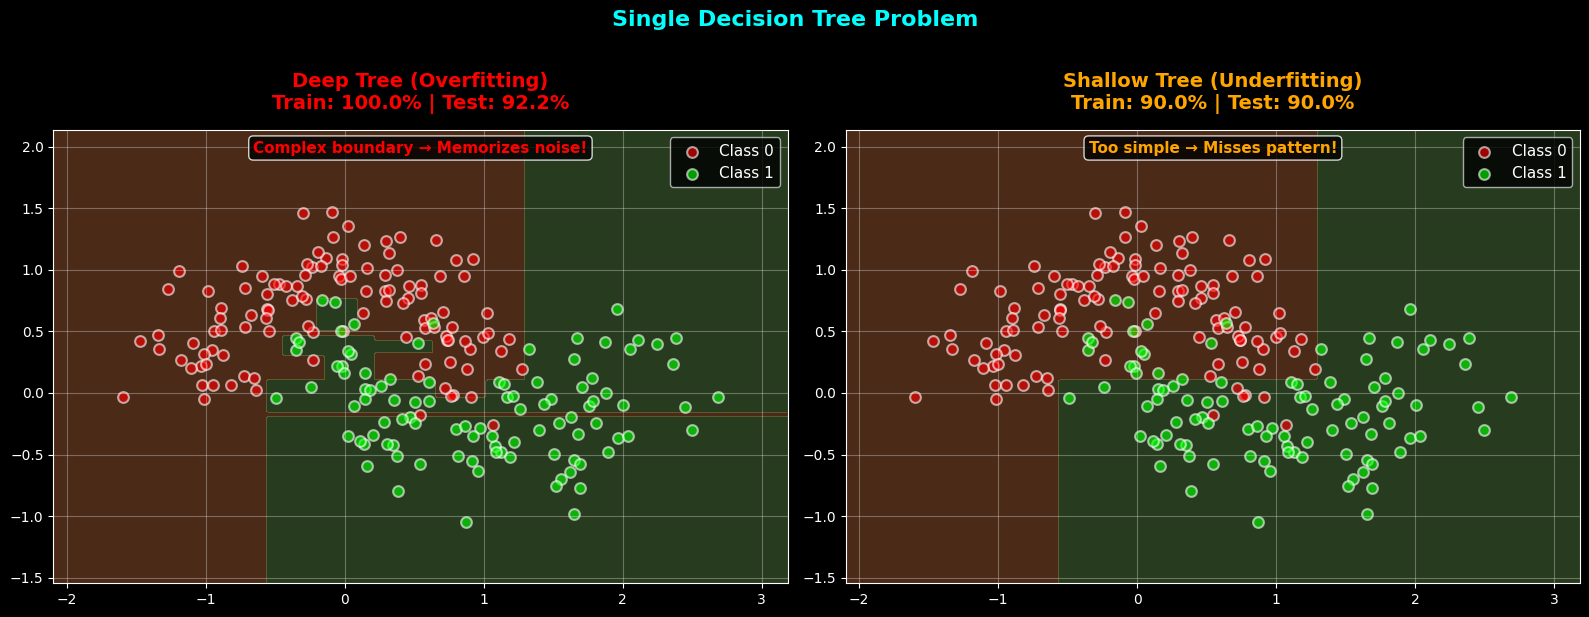

SINGLE TREE PROBLEM:
Deep Tree (No max_depth):
  Train Accuracy: 100.0%
  Test Accuracy:  92.2%
  Gap: 7.8% (OVERFITTING!)

Shallow Tree (max_depth=2):
  Train Accuracy: 90.0%
  Test Accuracy:  90.0%

DILEMMA: Deep → Overfit, Shallow → Underfit

SOLUTION: RANDOM FOREST! 🌳🌳🌳


In [2]:
# Generate noisy dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a deep decision tree (prone to overfitting)
tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_overfit.fit(X_train, y_train)

# Train a shallow tree (underfitting)
tree_underfit = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_underfit.fit(X_train, y_train)

# Create meshgrid for decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predictions
Z_overfit = tree_overfit.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_underfit = tree_underfit.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overfitted tree
axes[0].contourf(xx, yy, Z_overfit, alpha=0.3, cmap='RdYlGn', levels=1)
axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
               c='red', s=60, alpha=0.6, edgecolors='white', linewidth=1.5, label='Class 0')
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
               c='lime', s=60, alpha=0.6, edgecolors='white', linewidth=1.5, label='Class 1')
axes[0].set_title(f'Deep Tree (Overfitting)\nTrain: {tree_overfit.score(X_train, y_train):.1%} | Test: {tree_overfit.score(X_test, y_test):.1%}', 
                 fontsize=14, fontweight='bold', color='red', pad=15)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

axes[0].text(0.5, 0.95, 'Complex boundary → Memorizes noise!', 
            transform=axes[0].transAxes, ha='center', fontsize=11, 
            color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

# Underfitted tree
axes[1].contourf(xx, yy, Z_underfit, alpha=0.3, cmap='RdYlGn', levels=1)
axes[1].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
               c='red', s=60, alpha=0.6, edgecolors='white', linewidth=1.5, label='Class 0')
axes[1].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
               c='lime', s=60, alpha=0.6, edgecolors='white', linewidth=1.5, label='Class 1')
axes[1].set_title(f'Shallow Tree (Underfitting)\nTrain: {tree_underfit.score(X_train, y_train):.1%} | Test: {tree_underfit.score(X_test, y_test):.1%}', 
                 fontsize=14, fontweight='bold', color='orange', pad=15)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

axes[1].text(0.5, 0.95, 'Too simple → Misses pattern!', 
            transform=axes[1].transAxes, ha='center', fontsize=11, 
            color='orange', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

plt.suptitle('Single Decision Tree Problem', fontsize=16, fontweight='bold', color='cyan', y=1.02)
plt.tight_layout()
plt.show()

print("SINGLE TREE PROBLEM:")
print("="*70)
print(f"Deep Tree (No max_depth):")
print(f"  Train Accuracy: {tree_overfit.score(X_train, y_train):.1%}")
print(f"  Test Accuracy:  {tree_overfit.score(X_test, y_test):.1%}")
print(f"  Gap: {(tree_overfit.score(X_train, y_train) - tree_overfit.score(X_test, y_test))*100:.1f}% (OVERFITTING!)")
print(f"\nShallow Tree (max_depth=2):")
print(f"  Train Accuracy: {tree_underfit.score(X_train, y_train):.1%}")
print(f"  Test Accuracy:  {tree_underfit.score(X_test, y_test):.1%}")
print("\nDILEMMA: Deep → Overfit, Shallow → Underfit")
print("\nSOLUTION: RANDOM FOREST! 🌳🌳🌳")
print("="*70)

## 2. Bootstrap Sampling (Bagging)

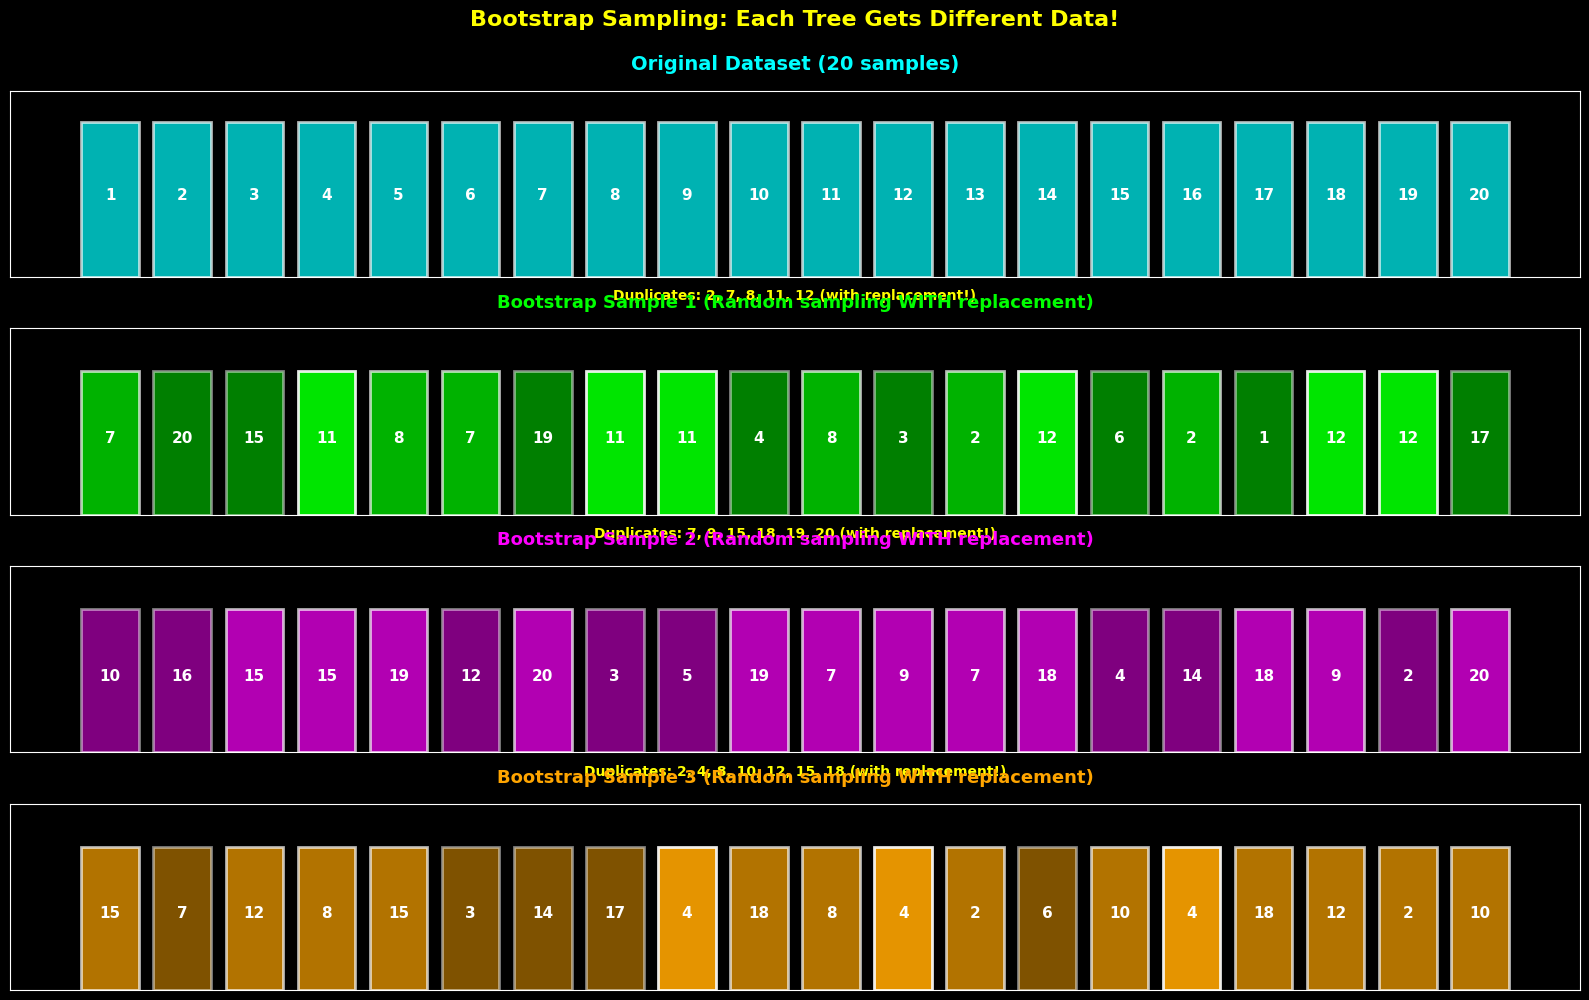


BOOTSTRAP SAMPLING (Bagging):
PROCESS: Random sampling WITH replacement
  - Same size as original (20 samples)
  - Some samples appear multiple times
  - Some samples never appear (~37% left out)

RESULT: Each tree sees DIFFERENT data!

WHY?
  - Creates diversity among trees
  - Each tree learns different patterns
  - Reduces correlation between trees

Out-of-Bag (OOB) samples:
  - ~37% not selected in each bootstrap
  - Used for validation (free test set!)


In [3]:
# Visualize bootstrap sampling
n_samples = 20
original_data = np.arange(1, n_samples + 1)

# Create 3 bootstrap samples
np.random.seed(42)
n_bootstraps = 3
bootstrap_samples = []

for i in range(n_bootstraps):
    bootstrap = np.random.choice(original_data, size=n_samples, replace=True)
    bootstrap_samples.append(bootstrap)

# Visualize
fig, axes = plt.subplots(4, 1, figsize=(16, 10))

# Original data
axes[0].bar(range(n_samples), np.ones(n_samples), color='cyan', 
           alpha=0.7, edgecolor='white', linewidth=2)
for i, val in enumerate(original_data):
    axes[0].text(i, 0.5, str(val), ha='center', fontsize=11, 
                fontweight='bold', color='white')
axes[0].set_title('Original Dataset (20 samples)', 
                 fontsize=14, fontweight='bold', color='cyan', pad=15)
axes[0].set_ylim(0, 1.2)
axes[0].set_yticks([])
axes[0].set_xticks([])

# Bootstrap samples
colors_boot = ['lime', 'magenta', 'orange']
for idx, (sample, color) in enumerate(zip(bootstrap_samples, colors_boot)):
    ax = axes[idx + 1]
    
    # Count occurrences
    unique, counts = np.unique(sample, return_counts=True)
    
    # Plot
    for i in range(n_samples):
        val = sample[i]
        # Height based on how many times this value appears
        count = counts[unique == val][0]
        alpha_val = min(0.3 + count * 0.2, 1.0)
        
        ax.bar(i, 1, color=color, alpha=alpha_val, 
              edgecolor='white', linewidth=2)
        ax.text(i, 0.5, str(val), ha='center', fontsize=11, 
               fontweight='bold', color='white')
    
    # Highlight duplicates
    duplicates = unique[counts > 1]
    if len(duplicates) > 0:
        dup_text = f"Duplicates: {', '.join(map(str, duplicates))} (with replacement!)"
        ax.text(0.5, 1.15, dup_text, transform=ax.transAxes, 
               ha='center', fontsize=10, color='yellow', fontweight='bold')
    
    ax.set_title(f'Bootstrap Sample {idx+1} (Random sampling WITH replacement)', 
                fontsize=13, fontweight='bold', color=color, pad=15)
    ax.set_ylim(0, 1.3)
    ax.set_yticks([])
    ax.set_xticks([])

plt.suptitle('Bootstrap Sampling: Each Tree Gets Different Data!', 
            fontsize=16, fontweight='bold', color='yellow', y=0.995)
plt.tight_layout()
plt.show()

print("\nBOOTSTRAP SAMPLING (Bagging):")
print("="*70)
print("PROCESS: Random sampling WITH replacement")
print("  - Same size as original (20 samples)")
print("  - Some samples appear multiple times")
print("  - Some samples never appear (~37% left out)")
print("\nRESULT: Each tree sees DIFFERENT data!")
print("\nWHY?")
print("  - Creates diversity among trees")
print("  - Each tree learns different patterns")
print("  - Reduces correlation between trees")
print("\nOut-of-Bag (OOB) samples:")
print("  - ~37% not selected in each bootstrap")
print("  - Used for validation (free test set!)")
print("="*70)

## 3. Random Feature Selection at Each Split

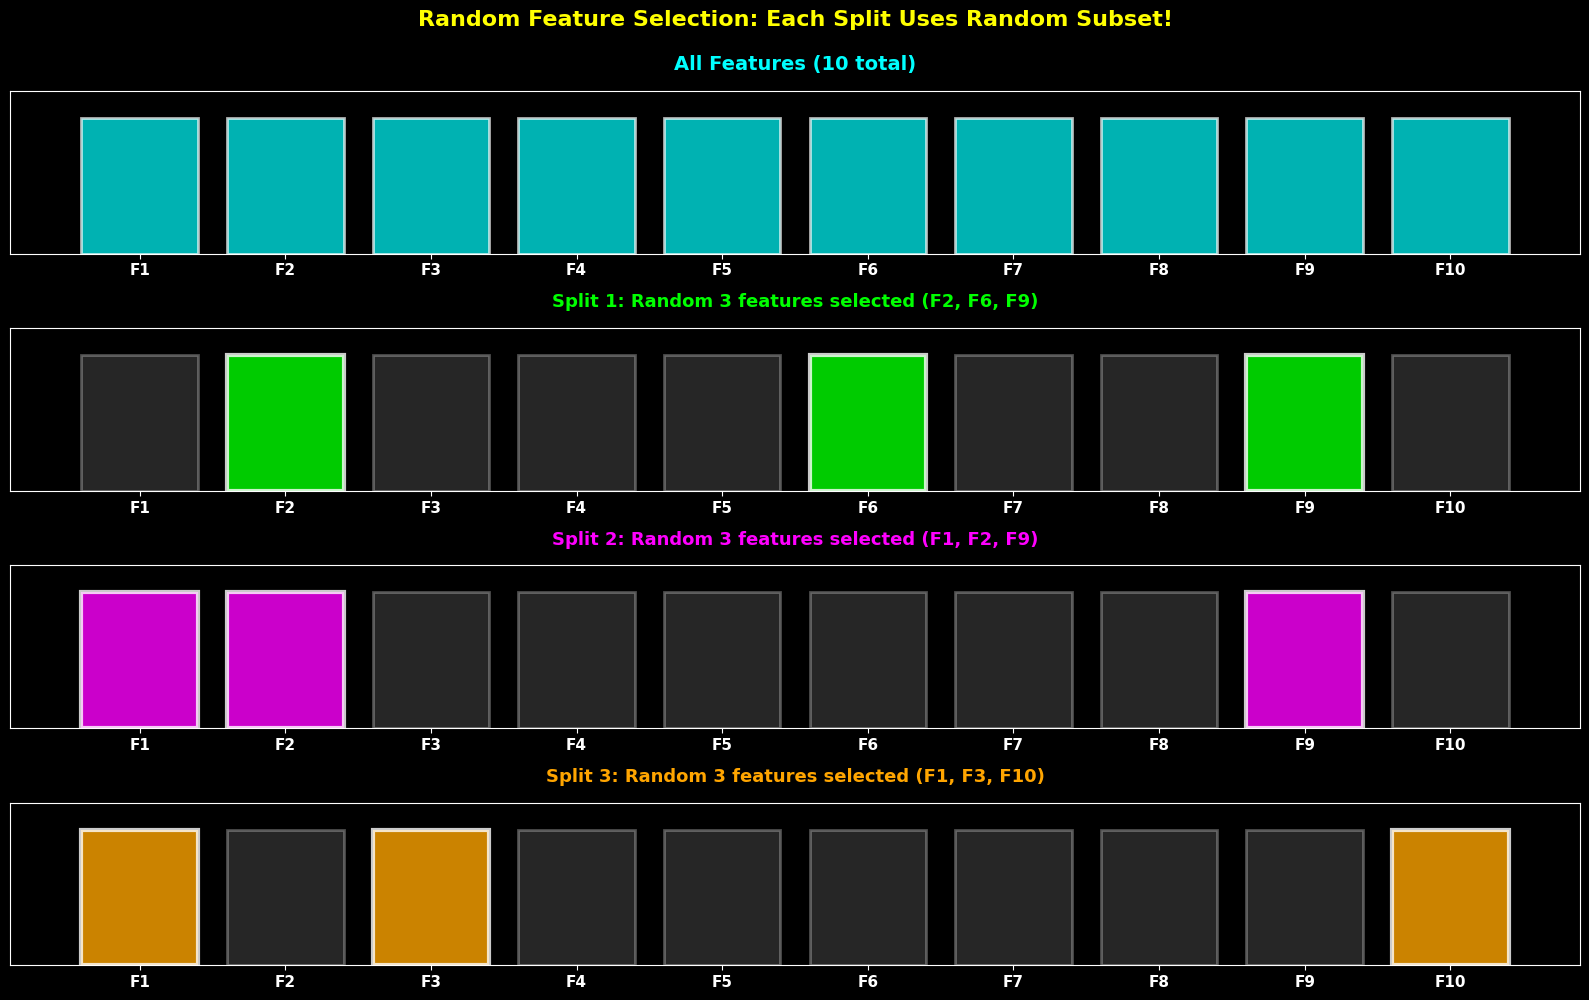


RANDOM FEATURE SELECTION:
Total features: 10
Features per split: 3 (sqrt(10))

AT EACH SPLIT:
  1. Randomly select subset of features
  2. Find best split among ONLY those features
  3. Different splits use different features

WHY?
  - Prevents strong features from dominating
  - Forces trees to use different features
  - Creates diversity among trees
  - Reduces correlation

COMMON CHOICES:
  - Classification: sqrt(n_features)
  - Regression: n_features / 3
  - Tune with cross-validation


In [4]:
# Visualize random feature selection
total_features = 10
max_features = int(np.sqrt(total_features))  # Common: sqrt(n_features)

feature_names = [f'F{i+1}' for i in range(total_features)]

# Simulate 3 different splits
np.random.seed(42)
n_splits = 3

fig, axes = plt.subplots(n_splits + 1, 1, figsize=(16, 10))

# Show all features
axes[0].bar(range(total_features), np.ones(total_features), 
           color='cyan', alpha=0.7, edgecolor='white', linewidth=2)
axes[0].set_xticks(range(total_features))
axes[0].set_xticklabels(feature_names, fontsize=11, fontweight='bold')
axes[0].set_title(f'All Features ({total_features} total)', 
                 fontsize=14, fontweight='bold', color='cyan', pad=15)
axes[0].set_ylim(0, 1.2)
axes[0].set_yticks([])

# Show random subsets for each split
colors_split = ['lime', 'magenta', 'orange']
for split_idx in range(n_splits):
    ax = axes[split_idx + 1]
    
    # Random feature selection
    selected_features = np.random.choice(total_features, size=max_features, replace=False)
    
    # Plot all features, highlight selected
    for i in range(total_features):
        if i in selected_features:
            ax.bar(i, 1, color=colors_split[split_idx], alpha=0.8, 
                  edgecolor='white', linewidth=3)
        else:
            ax.bar(i, 1, color='gray', alpha=0.3, 
                  edgecolor='white', linewidth=2)
    
    ax.set_xticks(range(total_features))
    ax.set_xticklabels(feature_names, fontsize=11, fontweight='bold')
    ax.set_title(f'Split {split_idx+1}: Random {max_features} features selected ' + 
                f'({", ".join([feature_names[i] for i in sorted(selected_features)])})', 
                fontsize=13, fontweight='bold', color=colors_split[split_idx], pad=15)
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])

plt.suptitle('Random Feature Selection: Each Split Uses Random Subset!', 
            fontsize=16, fontweight='bold', color='yellow', y=0.995)
plt.tight_layout()
plt.show()

print("\nRANDOM FEATURE SELECTION:")
print("="*70)
print(f"Total features: {total_features}")
print(f"Features per split: {max_features} (sqrt({total_features}))")
print("\nAT EACH SPLIT:")
print("  1. Randomly select subset of features")
print("  2. Find best split among ONLY those features")
print("  3. Different splits use different features")
print("\nWHY?")
print("  - Prevents strong features from dominating")
print("  - Forces trees to use different features")
print("  - Creates diversity among trees")
print("  - Reduces correlation")
print("\nCOMMON CHOICES:")
print("  - Classification: sqrt(n_features)")
print("  - Regression: n_features / 3")
print("  - Tune with cross-validation")
print("="*70)

## 4. Voting: Combining Predictions

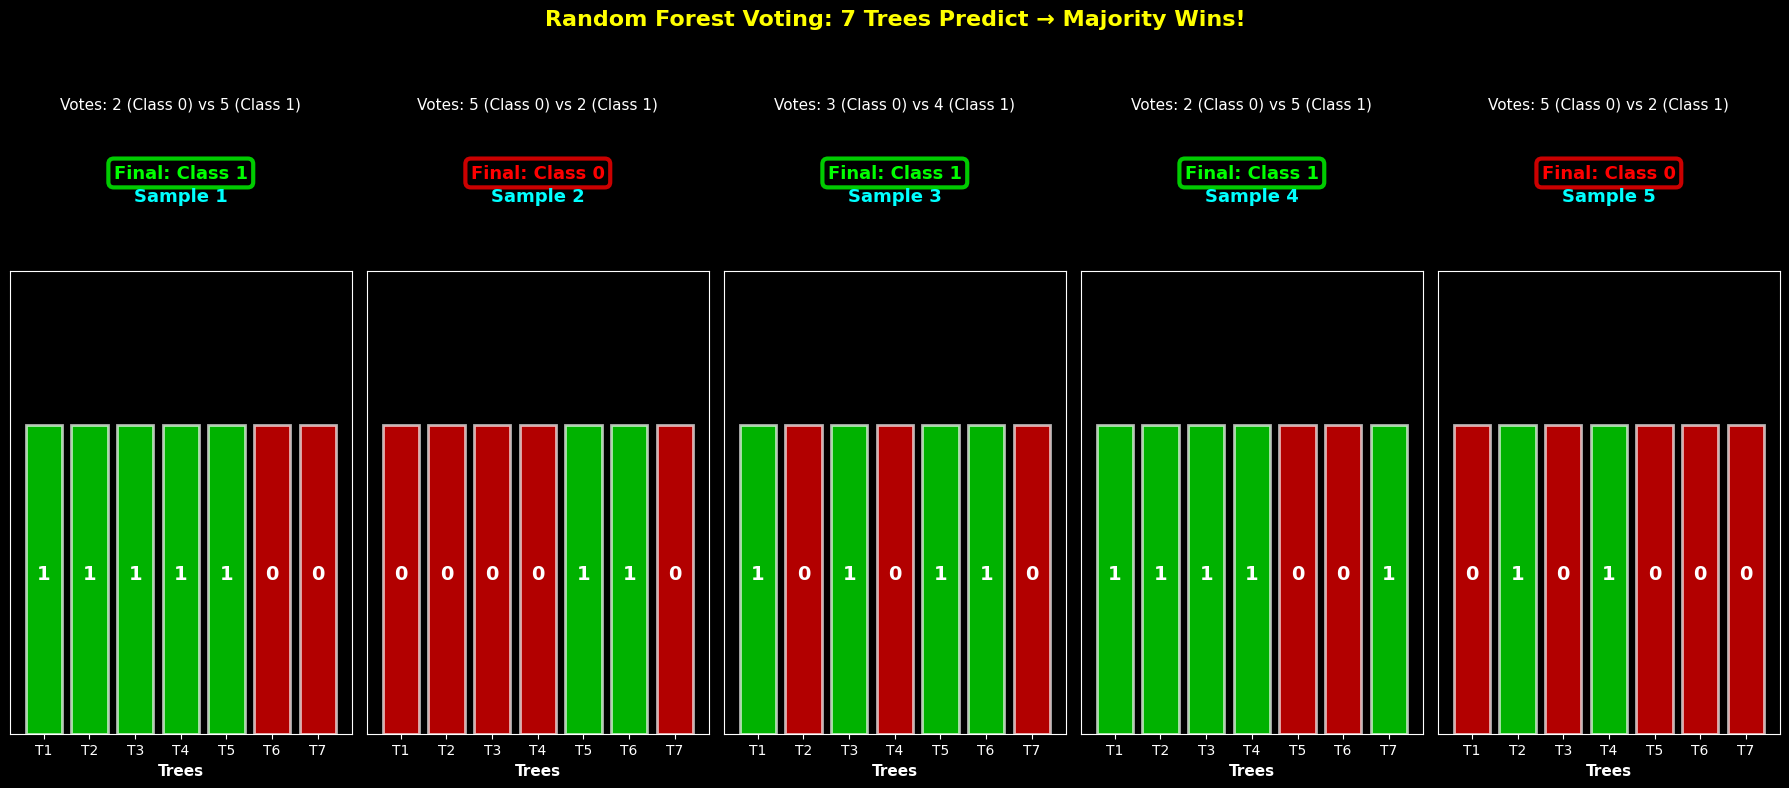


VOTING MECHANISM:
CLASSIFICATION: Majority vote
  - 7 trees predict
  - Each tree votes for a class
  - Final prediction = class with most votes

EXAMPLES:
  Sample 1: 2-5 → Class 1
  Sample 2: 5-2 → Class 0
  Sample 3: 3-4 → Class 1
  Sample 4: 2-5 → Class 1
  Sample 5: 5-2 → Class 0

REGRESSION: Average predictions
  - Tree 1: 100
  - Tree 2: 105
  - Tree 3: 98
  - Final: (100+105+98)/3 = 101

WHY VOTING WORKS?
  - Averages out individual tree errors
  - Reduces variance
  - More stable predictions


In [5]:
# Simulate predictions from multiple trees
n_trees = 7
n_test_samples = 5

# Simulate predictions (0 or 1)
np.random.seed(42)
predictions = np.random.randint(0, 2, (n_trees, n_test_samples))

# Manually adjust to show interesting voting patterns
predictions[:, 0] = [1, 1, 1, 1, 1, 0, 0]  # Strong consensus for class 1
predictions[:, 1] = [0, 0, 0, 0, 1, 1, 0]  # Strong consensus for class 0
predictions[:, 2] = [1, 0, 1, 0, 1, 1, 0]  # Close call (4-3)
predictions[:, 3] = [1, 1, 1, 1, 0, 0, 1]  # Majority class 1 (5-2)
predictions[:, 4] = [0, 1, 0, 1, 0, 0, 0]  # Majority class 0 (5-2)

# Majority vote
final_predictions = (predictions.sum(axis=0) > n_trees/2).astype(int)

# Visualize
fig, axes = plt.subplots(1, n_test_samples, figsize=(18, 8))

for sample_idx in range(n_test_samples):
    ax = axes[sample_idx]
    
    votes = predictions[:, sample_idx]
    votes_0 = np.sum(votes == 0)
    votes_1 = np.sum(votes == 1)
    final_pred = final_predictions[sample_idx]
    
    # Bar chart of tree predictions
    colors_vote = ['red' if v == 0 else 'lime' for v in votes]
    ax.bar(range(n_trees), np.ones(n_trees), color=colors_vote, 
          alpha=0.7, edgecolor='white', linewidth=2)
    
    for i, vote in enumerate(votes):
        ax.text(i, 0.5, str(vote), ha='center', fontsize=14, 
               fontweight='bold', color='white')
    
    # Show vote counts
    ax.text(0.5, 1.35, f'Votes: {votes_0} (Class 0) vs {votes_1} (Class 1)', 
           transform=ax.transAxes, ha='center', fontsize=11, color='white')
    
    # Show final prediction
    final_color = 'lime' if final_pred == 1 else 'red'
    ax.text(0.5, 1.20, f'Final: Class {final_pred}', 
           transform=ax.transAxes, ha='center', fontsize=13, 
           fontweight='bold', color=final_color,
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                    edgecolor=final_color, linewidth=3))
    
    ax.set_title(f'Sample {sample_idx+1}', fontsize=13, fontweight='bold', 
                color='cyan', pad=50)
    ax.set_ylim(0, 1.5)
    ax.set_yticks([])
    ax.set_xticks(range(n_trees))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_trees)], fontsize=10)
    ax.set_xlabel('Trees', fontsize=11, fontweight='bold')

plt.suptitle(f'Random Forest Voting: {n_trees} Trees Predict → Majority Wins!', 
            fontsize=16, fontweight='bold', color='yellow', y=0.98)
plt.tight_layout()
plt.show()

print("\nVOTING MECHANISM:")
print("="*70)
print("CLASSIFICATION: Majority vote")
print(f"  - {n_trees} trees predict")
print("  - Each tree votes for a class")
print("  - Final prediction = class with most votes")
print("\nEXAMPLES:")
for i in range(n_test_samples):
    votes = predictions[:, i]
    votes_0 = np.sum(votes == 0)
    votes_1 = np.sum(votes == 1)
    final = final_predictions[i]
    print(f"  Sample {i+1}: {votes_0}-{votes_1} → Class {final}")

print("\nREGRESSION: Average predictions")
print("  - Tree 1: 100")
print("  - Tree 2: 105")
print("  - Tree 3: 98")
print("  - Final: (100+105+98)/3 = 101")
print("\nWHY VOTING WORKS?")
print("  - Averages out individual tree errors")
print("  - Reduces variance")
print("  - More stable predictions")
print("="*70)

## 5. Random Forest vs Single Tree: The Showdown

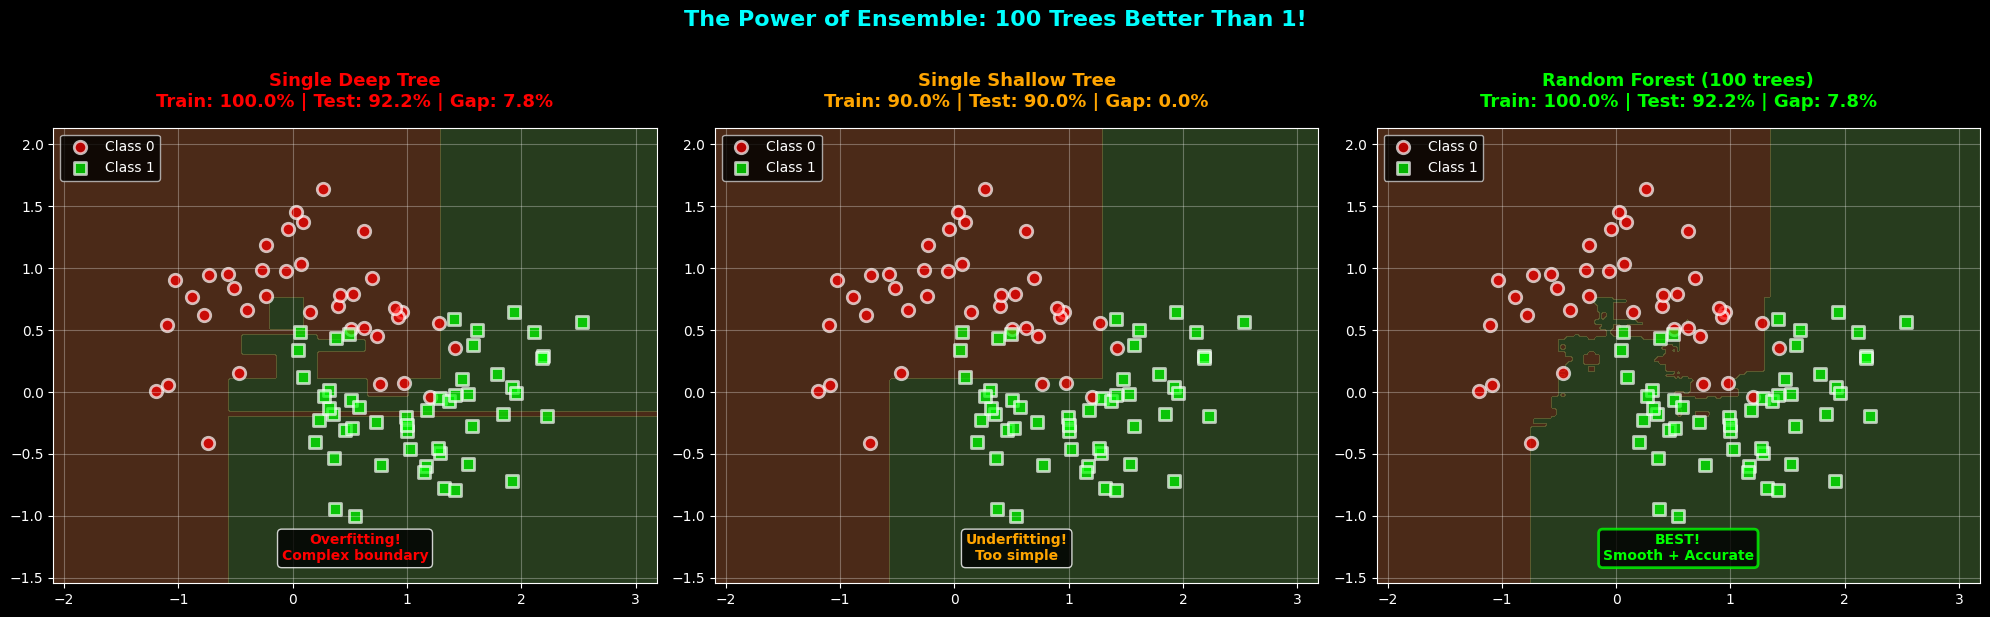


PERFORMANCE COMPARISON:
Single Deep Tree (Overfit):
  Train: 100.0%
  Test:  92.2%
  Gap:   7.8% ✗

Single Shallow Tree (Underfit):
  Train: 90.0%
  Test:  90.0%

Random Forest (100 trees):
  Train: 100.0%
  Test:  92.2%
  Gap:   7.8% ✓ BEST!

WINNER: Random Forest! 🏆
  - Better generalization
  - Lower variance
  - Smoother decision boundary


In [6]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=None, 
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
Z_rf = rf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = [
    {'name': 'Single Deep Tree', 'model': tree_overfit, 'Z': Z_overfit, 'color': 'red'},
    {'name': 'Single Shallow Tree', 'model': tree_underfit, 'Z': Z_underfit, 'color': 'orange'},
    {'name': 'Random Forest (100 trees)', 'model': rf, 'Z': Z_rf, 'color': 'lime'}
]

for idx, model_info in enumerate(models):
    ax = axes[idx]
    model = model_info['model']
    Z = model_info['Z']
    
    # Decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn', levels=1)
    
    # Data points
    ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
              c='red', s=80, alpha=0.7, edgecolors='white', 
              linewidth=2, label='Class 0', marker='o')
    ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
              c='lime', s=80, alpha=0.7, edgecolors='white', 
              linewidth=2, label='Class 1', marker='s')
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc
    
    ax.set_title(f"{model_info['name']}\nTrain: {train_acc:.1%} | Test: {test_acc:.1%} | Gap: {gap*100:.1f}%", 
                fontsize=13, fontweight='bold', color=model_info['color'], pad=15)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.3)

# Add annotations
axes[0].text(0.5, 0.05, 'Overfitting!\nComplex boundary', 
            transform=axes[0].transAxes, ha='center', fontsize=10, 
            color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

axes[1].text(0.5, 0.05, 'Underfitting!\nToo simple', 
            transform=axes[1].transAxes, ha='center', fontsize=10, 
            color='orange', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

axes[2].text(0.5, 0.05, 'BEST!\nSmooth + Accurate', 
            transform=axes[2].transAxes, ha='center', fontsize=10, 
            color='lime', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                     edgecolor='lime', linewidth=2))

plt.suptitle('The Power of Ensemble: 100 Trees Better Than 1!', 
            fontsize=16, fontweight='bold', color='cyan', y=1.02)
plt.tight_layout()
plt.show()

print("\nPERFORMANCE COMPARISON:")
print("="*70)
print(f"Single Deep Tree (Overfit):")
print(f"  Train: {tree_overfit.score(X_train, y_train):.1%}")
print(f"  Test:  {tree_overfit.score(X_test, y_test):.1%}")
print(f"  Gap:   {(tree_overfit.score(X_train, y_train) - tree_overfit.score(X_test, y_test))*100:.1f}% ✗")
print(f"\nSingle Shallow Tree (Underfit):")
print(f"  Train: {tree_underfit.score(X_train, y_train):.1%}")
print(f"  Test:  {tree_underfit.score(X_test, y_test):.1%}")
print(f"\nRandom Forest (100 trees):")
print(f"  Train: {rf.score(X_train, y_train):.1%}")
print(f"  Test:  {rf.score(X_test, y_test):.1%}")
print(f"  Gap:   {(rf.score(X_train, y_train) - rf.score(X_test, y_test))*100:.1f}% ✓ BEST!")
print("\nWINNER: Random Forest! 🏆")
print("  - Better generalization")
print("  - Lower variance")
print("  - Smoother decision boundary")
print("="*70)

## 6. One Complete Example: Step-by-Step

In [7]:
# Simple illustrative example
print("\nRANDOM FOREST: COMPLETE EXAMPLE")
print("="*70)
print("\nTASK: Predict loan approval")
print("Features: Age, Income, Credit Score")
print("Training data: 1000 samples")
print("\n" + "="*70)

print("\nSTEP 1: BUILD TREE 1")
print("-" * 70)
print("  1a. Bootstrap sample: Randomly pick 1000 samples WITH replacement")
print("      Example: [Sample 5, Sample 102, Sample 5, Sample 34, ...]")
print("      Note: Sample 5 appears twice!")
print("\n  1b. Build tree:")
print("      At each split, randomly select sqrt(3) = 2 features")
print("      - Split 1: Use [Age, Income] → Best: Income > 50K")
print("      - Split 2: Use [Age, Credit] → Best: Age > 30")
print("      - ...continue until stopping criteria")
print("\n  1c. Tree 1 complete! Predictions: [1, 0, 1, 1, 0, ...]")

print("\n" + "="*70)
print("\nSTEP 2: BUILD TREE 2")
print("-" * 70)
print("  2a. NEW bootstrap sample (different from Tree 1!)")
print("      Example: [Sample 200, Sample 15, Sample 200, Sample 89, ...]")
print("\n  2b. Build tree:")
print("      Again, random 2 features at each split")
print("      - Split 1: Use [Income, Credit] → Best: Credit > 650")
print("      - Split 2: Use [Age, Income] → Best: Income > 40K")
print("      Different splits than Tree 1!")
print("\n  2c. Tree 2 complete! Predictions: [1, 1, 1, 0, 0, ...]")

print("\n" + "="*70)
print("\nSTEP 3: BUILD TREES 3-100")
print("-" * 70)
print("  Repeat process for all 100 trees")
print("  Each tree:")
print("    - Different bootstrap sample")
print("    - Different random features at splits")
print("    - Different structure")
print("  Result: 100 diverse trees! 🌳🌳🌳")

print("\n" + "="*70)
print("\nSTEP 4: PREDICTION (New customer)")
print("-" * 70)
print("  Input: Age=35, Income=60K, Credit=700")
print("\n  Each tree predicts:")
print("    Tree 1:  Approve (1)")
print("    Tree 2:  Approve (1)")
print("    Tree 3:  Reject (0)")
print("    Tree 4:  Approve (1)")
print("    ...")
print("    Tree 100: Approve (1)")
print("\n  Vote count: 73 Approve, 27 Reject")
print("  FINAL: Approve (Majority wins!) ✓")

print("\n" + "="*70)
print("\nWHY IT WORKS:")
print("-" * 70)
print("  1. DIVERSITY: Each tree different (bootstrap + random features)")
print("  2. WISDOM OF CROWDS: Average out individual errors")
print("  3. VARIANCE REDUCTION: Stable predictions")
print("  4. OVERFITTING PREVENTION: No single tree dominates")
print("\n  Single tree: Might overfit to noise")
print("  100 trees: Average cancels out noise! 🎯")
print("="*70)


RANDOM FOREST: COMPLETE EXAMPLE

TASK: Predict loan approval
Features: Age, Income, Credit Score
Training data: 1000 samples


STEP 1: BUILD TREE 1
----------------------------------------------------------------------
  1a. Bootstrap sample: Randomly pick 1000 samples WITH replacement
      Example: [Sample 5, Sample 102, Sample 5, Sample 34, ...]
      Note: Sample 5 appears twice!

  1b. Build tree:
      At each split, randomly select sqrt(3) = 2 features
      - Split 1: Use [Age, Income] → Best: Income > 50K
      - Split 2: Use [Age, Credit] → Best: Age > 30
      - ...continue until stopping criteria

  1c. Tree 1 complete! Predictions: [1, 0, 1, 1, 0, ...]


STEP 2: BUILD TREE 2
----------------------------------------------------------------------
  2a. NEW bootstrap sample (different from Tree 1!)
      Example: [Sample 200, Sample 15, Sample 200, Sample 89, ...]

  2b. Build tree:
      Again, random 2 features at each split
      - Split 1: Use [Income, Credit] → Best: Cr

## 7. Key Takeaways

### Random Forest = Ensemble of Decision Trees

**Core Concept:**
- Train many decision trees
- Each tree different (diversity!)
- Combine predictions by voting/averaging

### The Two Key Ingredients:

**1. Bagging (Bootstrap Aggregating):**
- Create bootstrap samples (random WITH replacement)
- Each tree trained on different sample
- ~63% unique samples, ~37% duplicates per tree
- OOB (Out-of-Bag) samples used for validation

**2. Random Feature Selection:**
- At each split, randomly select subset of features
- Common: sqrt(n_features) for classification
- Common: n_features/3 for regression
- Prevents strong features from dominating

### How It Works:

**Training:**
1. For each tree (1 to n_estimators):
   - Create bootstrap sample
   - Build decision tree:
     - At each split, use random subset of features
     - Find best split among those features
     - Repeat recursively
2. Store all trees

**Prediction:**
- **Classification**: Each tree votes, majority wins
- **Regression**: Each tree predicts, average them

### Why It's Better Than Single Tree:

**Single Tree Problems:**
- ✗ High variance (sensitive to data changes)
- ✗ Overfitting (especially deep trees)
- ✗ Unstable (small data change → big tree change)

**Random Forest Solutions:**
- ✓ Lower variance (averaging reduces it)
- ✓ Less overfitting (ensemble generalizes better)
- ✓ More stable (voting cancels outliers)
- ✓ Better accuracy (wisdom of crowds)

### Advantages:
- ✓ Excellent performance (often top-tier)
- ✓ Handles non-linear relationships
- ✓ No feature scaling needed
- ✓ Feature importance built-in
- ✓ Handles missing values
- ✓ Reduces overfitting
- ✓ Parallel training (fast with n_jobs=-1)
- ✓ OOB error for validation

### Disadvantages:
- ✗ Less interpretable (100 trees vs 1 tree)
- ✗ Larger model size (stores all trees)
- ✗ Slower prediction (100 trees to evaluate)
- ✗ Memory intensive

### Hyperparameters:

**n_estimators:**
- Number of trees
- More = Better (diminishing returns after ~100)
- Common: 100-500

**max_features:**
- Features to consider per split
- sqrt(n) for classification (default)
- n/3 for regression

**max_depth:**
- Maximum tree depth
- None = fully grown trees (default)
- Can limit for speed

**min_samples_split / min_samples_leaf:**
- Stopping criteria
- Higher = more regularization

### Best Practices:

**1. Start with defaults:**
```python
rf = RandomForestClassifier(n_estimators=100, random_state=42)
```

**2. Use OOB for quick validation:**
```python
rf = RandomForestClassifier(oob_score=True)
rf.fit(X_train, y_train)
print(f"OOB Score: {rf.oob_score_}")
```

**3. Parallelize:**
```python
rf = RandomForestClassifier(n_jobs=-1)  # Use all cores
```

**4. Feature importance:**
```python
importances = rf.feature_importances_
```

### When to Use:

**✓ Use Random Forest when:**
- Need high accuracy
- Have tabular data
- Don't need interpretability
- Have moderate dataset size
- Want feature importance
- Need robust model (handles noise well)

**✗ Don't use when:**
- Need interpretability (use single tree)
- Have very large dataset (use XGBoost/LightGBM)
- Have text/image data (use deep learning)
- Need fastest prediction (use linear models)

### Remember:
- **100 trees > 1 tree** (ensemble is king!)
- **Diversity is key** (bootstrap + random features)
- **Voting averages errors** (wisdom of crowds)
- **No feature scaling needed** (tree-based)
- **Excellent default choice** for classification/regression! 🌳🌳🌳